In [6]:
import pandas as pd

df_raw = pd.read_excel(r'../data/credit_risk_dataset_v2_sample10k.xlsx', sheet_name='Customer Data')
print(df_raw.shape)

(10000, 538)


In [7]:
df_raw.head(5)

,customer_id,risk_attribute_770487,risk_attribute_216739,risk_attribute_126225,risk_attribute_877572,risk_attribute_388389,risk_attribute_356787,risk_attribute_334053,risk_attribute_246316,risk_attribute_872246,...,risk_attribute_815198,risk_attribute_361650,risk_attribute_799330,risk_attribute_207786,risk_attribute_470858,risk_attribute_918011,risk_attribute_687080,risk_attribute_526117,risk_attribute_750810,risk_attribute_885884
0,CUST_0075722,0,0,0,0,0,0,0,0,0,...,3,111192,249174,0.0000,0,6,600,0,61,0
1,CUST_0080185,0,0,0,0,0,0,0,0,0,...,3,71956,140025,0.0000,0,7,600,2,66,1
2,CUST_0019865,0,0,0,0,0,0,0,0,0,...,4,114942,110394,1.6949,0,4,600,1,41,1
3,CUST_0076700,0,0,0,0,0,0,0,0,0,...,4,186962,0,1.8173,0,3,600,1,28,0
4,CUST_0092992,0,0,0,0,0,0,0,0,0,...,2,0,41517,1.2807,0,3,600,0,61,0


In [ ]:
#target columns
# a customer flagged `bad = 1` if any of three risk attributes cross a threshold (one ≥ 8, two others > 0), else `0`
df_raw['bad'] = (
    (df_raw['risk_attribute_383060'] >= 8) |
    (df_raw['risk_attribute_274389'] > 0) |
    (df_raw['risk_attribute_272634'] > 0)
).astype(int)
#  value_counts and mean show the class balance and the resulting bad rate.
print(df_raw['bad'].value_counts())
print("Bad rate:", df_raw['bad'].mean())
# the three columns used to *build* the label are stored in `leakage_cols` and dropped from the features otherwise the model could cheat by learning the exact rule that defined the target. `customer_id` (an identifier, not a predictor) is also dropped.
leakage_cols = ['risk_attribute_383060', 'risk_attribute_274389', 'risk_attribute_272634']
X = df_raw.drop(columns=['customer_id', 'bad'] + leakage_cols)
y = df_raw['bad']
# The result is `X` (features) and `y` (target). The final line confirms there are no missing values.
print("X shape:", X.shape, "y shape:", y.shape)
print("Missing Values in dataset:", X.isnull().sum().sum())

bad
0    9841
1     159
Name: count, dtype: int64
Bad rate: 0.0159
X shape: (10000, 534) y shape: (10000,)
Missing Values in dataset: 0


In [11]:
#train test split 80/20
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(8000, 534) (2000, 534)
0.015875 0.016


In [12]:
# --- XGBoost: baseline model ---
# Only 1.59% of customers are "bad", so scale_pos_weight tells XGBoost to
# weight the rare positive class up by (n_negative / n_positive).
import numpy as np
from xgboost import XGBClassifier

spw = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(spw, 2))

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    scale_pos_weight=spw,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
)

xgb.fit(X_train, y_train)
print("Trained.")

scale_pos_weight: 61.99
Trained.


In [13]:
# --- Evaluation ---
# With a 1.6% bad rate, accuracy is misleading (predicting all-zero scores 98.4%).
# PR-AUC is the metric that matters for rare-event detection.
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
)

proba = xgb.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC :", round(roc_auc_score(y_test, proba), 4))
print("PR-AUC  :", round(average_precision_score(y_test, proba), 4))
print("Baseline PR-AUC (random):", round(y_test.mean(), 4))
print()
print(confusion_matrix(y_test, pred))
print()
print(classification_report(y_test, pred, digits=3))

ROC-AUC : 1.0
PR-AUC  : 1.0
Baseline PR-AUC (random): 0.016

[[1968    0]
 [   0   32]]

              precision    recall  f1-score   support

           0      1.000     1.000     1.000      1968
           1      1.000     1.000     1.000        32

    accuracy                          1.000      2000
   macro avg      1.000     1.000     1.000      2000
weighted avg      1.000     1.000     1.000      2000



In [14]:
# cross-validation check 
# 20% test split holds only 32 bad customers, so one split is noisy.
# Stratified 5-fold gives a more trustworthy estimate and a spread.
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb, X, y, cv=cv, scoring="average_precision", n_jobs=-1)

print("Fold PR-AUCs:", np.round(scores, 4))
print("Mean: %.4f  (+/- %.4f)" % (scores.mean(), scores.std()))

Fold PR-AUCs: [0.9741 1.     1.     1.     1.    ]
Mean: 0.9948  (+/- 0.0104)


<Axes: title={'center': 'Top 20 features by gain'}>

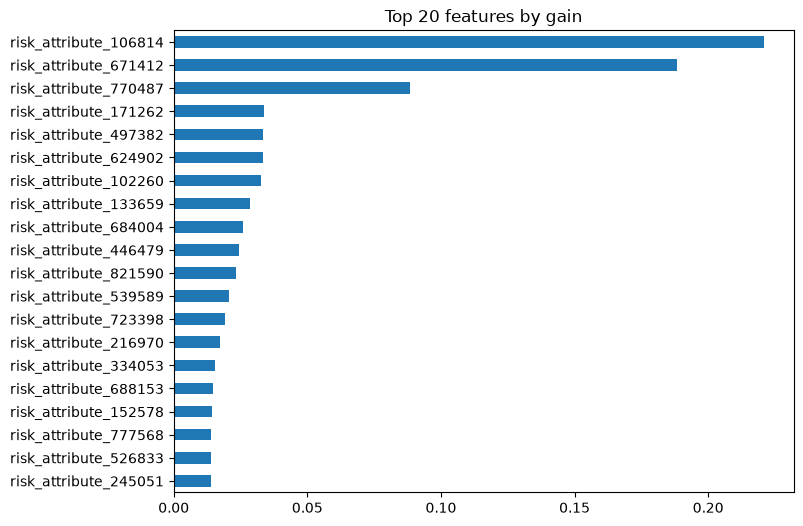

In [15]:
# top features
imp = (
    pd.Series(xgb.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(20)
)
imp.iloc[::-1].plot.barh(figsize=(8, 6), title="Top 20 features by gain")

In [16]:
#save model
import joblib

joblib.dump(xgb, "xgb_credit_risk_baseline.joblib")
print("Saved to models/xgb_credit_risk_baseline.joblib")

Saved to models/xgb_credit_risk_baseline.joblib
